In [ ]:
from google.colab import drive
drive.mount ('/content/drive')

Mounted at /content/drive


Epoch 10, MSE: 8.2614, MAPE: 749.42%
Epoch 20, MSE: 5.9246, MAPE: 519.63%
Epoch 30, MSE: 4.3202, MAPE: 330.37%
Epoch 40, MSE: 3.2087, MAPE: 176.52%
Epoch 50, MSE: 2.4376, MAPE: 101.96%


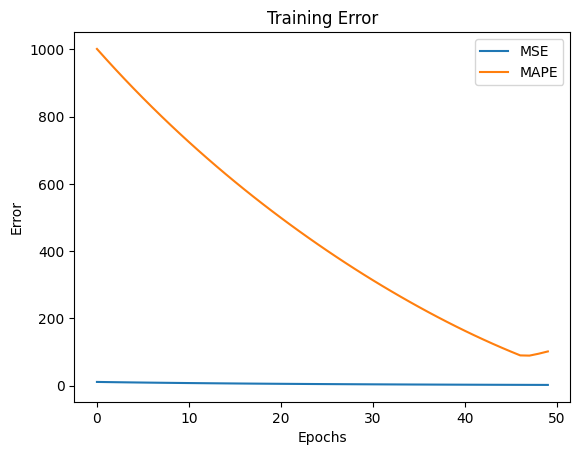

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# 시드 고정 및 데이터 생성
np.random.seed(0)
samples = 1000
x1 = np.random.uniform(0, 1, samples)
x2 = np.random.uniform(0, 1, samples)
X = np.column_stack((x1, x2))
y = 2 * x1 + 3 * x2 - 1
y = y.reshape(-1, 1)

# 하이퍼파라미터
input_dim = 2
hidden_dim = 3
output_dim = 1
learning_rate = 0.01
epochs = 50

# 시그모이드 함수 및 미분
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(z):
    return sigmoid(z) * (1 - sigmoid(z))

# 가중치 초기화 (Bias 포함을 위해 +1)
W1 = np.random.randn(input_dim + 1, hidden_dim)
W2 = np.random.randn(hidden_dim + 1, output_dim)

# 입력에 bias 1 추가
X_b = np.hstack((np.ones((samples, 1)), X))

# 학습
mse_list = []
mape_list = []

for epoch in range(epochs):
    # Forward
    Z1 = X_b @ W1
    A1 = sigmoid(Z1)
    A1_b = np.hstack((np.ones((samples, 1)), A1))  # 은닉층 출력에 bias 추가
    Z2 = A1_b @ W2
    y_hat = Z2

    # Loss 계산
    error = y_hat - y
    mse = np.mean(error**2)
    mape = np.mean(np.abs(error / y)) * 100
    mse_list.append(mse)
    mape_list.append(mape)

    # Backpropagation
    dZ2 = error
    dW2 = A1_b.T @ dZ2 / samples
    dA1 = dZ2 @ W2[1:].T
    dZ1 = dA1 * sigmoid_derivative(Z1)
    dW1 = X_b.T @ dZ1 / samples

    # 가중치 업데이트
    W1 -= learning_rate * dW1
    W2 -= learning_rate * dW2

    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}, MSE: {mse:.4f}, MAPE: {mape:.2f}%")

# 결과 시각화
plt.plot(mse_list, label='MSE')
plt.plot(mape_list, label='MAPE')
plt.xlabel('Epochs')
plt.ylabel('Error')
plt.legend()
plt.title('Training Error')
plt.show()

